##0. 필요한 라이브러리 불러오기

In [1]:
%pip install -q ortools

In [2]:
%pip install -q haversine

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from haversine import haversine

##1. 데이터 불러오기

In [4]:
import os
def find_data(name):
    """repo 루트 / notebooks 폴더 / Colab 업로드 위치 어디서 실행해도 데이터 파일을 찾음"""
    for p in [f"data/{name}", f"../data/{name}", name, f"/content/{name}"]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{name} 파일을 data/ 폴더에 넣어주세요")

df = pd.read_csv(find_data('detailed_ev_charging_stations.csv'))

##2. 데이터 전처리

0. 필요한 변수 설정

In [5]:
# 결정 변수
battery_capacity_kwh = 70   #차량별 베터리 용량
initial_soc_kwh = 1.0 * battery_capacity_kwh #초기 잔량 (kwh)
consumption_per_km = 0.15   #주행 에너지 소모량(kwh/km)
reserve_kwh=5.6             # 최소 잔량 (kwh)
v = 90                      #주행 속력 (km/h)

1) 필요한 열만 가져오기

"Station ID", #충전소 이름\
"Latitude", #위도\
"Longitude", #경도\
"Address", #주소\
"Charging Capacity (kW)", #충전속도\
"Charger Type", #급속 / 완속 / 테슬라 / CCS\
"Availability", #항상 가능/주말만/24시간 → 경로 제약\
"Usage Stats (avg users/day)", #혼잡도 예측, 가중치 설정, 대기시간 추정\
"Parking Spots", #충전 허용 차량 수\
"Cost (USD/kWh)", \
"Reviews (Rating)" \
\
중\
Latitude(위도), Longitude(경도), Charging Capacity(kW)(충전속도), Cost (USD/kWh)만 사용


In [6]:
needed_cols = [
    "Latitude", #위도
    "Longitude", #경도
    "Charging Capacity (kW)", #충전속도
    "Cost (USD/kWh)", #kWh 당 USD
]

df = df[needed_cols]

2. 각 충전소별 1kW 충전하는데 걸리는 시간(kWh) 및 비용(USD/kWh) 계산\
1 / Charging Capacity (kW)
Cost (USD/kWh)

In [7]:
time_per_kwh = 1.0 / df["Charging Capacity (kW)"].to_numpy(dtype=float)  # shape (N,)
price_per_kwh = df["Cost (USD/kWh)"].to_numpy(dtype=float)  # shape (N,)

3) 맵 생성하기

위도(latitude)와 경도(longitude) 좌표를 사용하여 지구 표면의 두 지점 간의 최단 거리를 계산\
(
구면(구체) 상의 거리를 계산하는 Haversine 공식을 구현한 것
)

dist_matrix : 모든 i,j에 대하여 i-> j이동에 걸리는 거리(km) 정보를 저장\
energy_matrix : i → j 이동에 필요한 배터리 에너지
(이동 거리 * 주행 에너지 소모량(kwh))

In [8]:
coords = list(zip(df["Latitude"], df["Longitude"]))
N = len(coords)
dist_matrix = np.zeros((N, N))      # km
time_matrix = np.zeros((N, N))      # hours
energy_matrix = np.zeros((N, N))    # kWh


for i in range(N):
    for j in range(N):
        if i == j:
            dist = 0.0
        else:
            dist = haversine(coords[i], coords[j])   # 기본 단위 km

        dist_matrix[i][j] = dist                                  # km i → j 이동 시 거리 (km)
        energy_matrix[i][j] = dist * consumption_per_km           # i → j 이동에 필요한 배터리 에너지 (kWh) / kWh

스케일링

In [9]:
dist = np.array(dist_matrix, dtype=np.float32)  # 메모리 절약

scaled_dist = np.log1p(dist) * 55    # log(1 + x)
scaled_time_matrix = scaled_dist / v

##3. 목적함수 및 제약조건 설정

In [10]:
# 제약조건 3. 다음 충전소 전까지는 무조건 최소 잔량 8%(5.6kWh)가 남아있다.
usable_energy_kwh = battery_capacity_kwh - reserve_kwh

drive_time = scaled_time_matrix.astype(float)

consumption_per_hour = v * consumption_per_km # 시간당 에너지 소모량 (kWh/hour)
energy_needed = drive_time * consumption_per_hour # i→j 구간에 필요한 에너지 = 시간 × (시간당 에너지 소모량)


time_per_kwh_row  = time_per_kwh.reshape(-1, 1)
price_per_kwh_row = price_per_kwh.reshape(-1, 1)


charge_time = energy_needed * time_per_kwh_row
charge_cost = energy_needed * price_per_kwh_row


# 갈 수 없는 간선 = INF 설정
INF = np.inf
feasible = (energy_needed <= usable_energy_kwh) & (dist > 0)

# 목적함수 가중치
w_drive_time = 1.0
w_charge_time = 1.0
w_charge_cost = 0.1

# 최종 목적함수 cost_matrix
cost_matrix = np.full_like(dist, INF, dtype=float)

cost_matrix[feasible] = (
    w_drive_time  * drive_time[feasible] +
    w_charge_time * charge_time[feasible] +
    w_charge_cost * charge_cost[feasible]
)

##4. 최적화 모델(ortools 사용) 및 시각화
min_cost_flow(MinCostFlow)

In [11]:
from ortools.graph.python import min_cost_flow

In [12]:
def shortest_path_ortools(start, end, cost_matrix):

    N = cost_matrix.shape[0]
    smcf = min_cost_flow.SimpleMinCostFlow()

    # 간선 추가
    for i in range(N):
        for j in range(N):
            if i == j: continue
            cost = cost_matrix[i][j]
            if np.isinf(cost): continue  # 불가능한 간선 버리기

            smcf.add_arc_with_capacity_and_unit_cost(
                i, j,
                1,
                int(cost * 1000)  # OR-Tools 정수 제약
            )

    # 제약조건 9. path는 출발지->도착지로 한 번만 간다.
    supplies = [0]*N
    supplies[start] = 1     #출발지: 들어오는 간선 0개, 나가는 간선 1개
    supplies[end] = -1      #도착지: 들어오는 간선 1개, 나가는 간선 0개
    for node in range(N):   #중간 노드 : 들어오는 간선의 수 = 나가는 간선의 수)
        smcf.set_node_supply(node, supplies[node])

    # Solve
    status = smcf.solve()
    if status != smcf.OPTIMAL:
        raise RuntimeError("경로 없음")

    # 경로 구성
    path = [start]
    cur = start
    while cur != end:
        found = False
        for arc in range(smcf.num_arcs()):
            if smcf.tail(arc) == cur and smcf.flow(arc) > 0:
                nxt = smcf.head(arc)
                path.append(nxt)
                cur = nxt
                found = True
                break
        if not found:
            raise RuntimeError("경로 구성 실패")

# 구간별(segment) 세부 정보
    segments = []
    for i, j in zip(path[:-1], path[1:]):
        segments.append({
            "from": i,
            "to": j,
            "drive_time":  float(drive_time[i][j]),
            "charge_time": float(charge_time[i][j]),
            "charge_cost": float(charge_cost[i][j]),
            "energy_used": float(energy_needed[i][j]),
        })

    total_cost = smcf.optimal_cost() / 1000.0

    return {
        "path": path,
        "segments": segments,
        "total_cost": total_cost,
    }

In [35]:
def plot_path_on_map(path, df):

    plt.figure(figsize=(8, 10))

    plt.scatter(df["Longitude"], df["Latitude"], s=5, alpha=0.5)

    path_lats = df.iloc[path]["Latitude"].values
    path_lons = df.iloc[path]["Longitude"].values

    plt.plot(path_lons, path_lats, marker="o", linewidth=2, markersize=6)

    plt.scatter(path_lons[0], path_lats[0], s=70, marker="s", label="Start")
    plt.scatter(path_lons[-1], path_lats[-1], s=70, marker="X", label="End")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Optimal EV Route")
    plt.grid(True)
    plt.legend()
    plt.show()

In [144]:
start_node = 57
end_node   = 3482

In [145]:
result_ortools = shortest_path_ortools(start_node, end_node, cost_matrix)

In [146]:
result_ortools['path']

[57, 3148, 2970, 1000, 21, 4050, 2860, 3230, 3410, 1960, 3482]

In [147]:
result_ortools['segments']

[{'from': 57,
  'to': 3148,
  'drive_time': 0.34656837582588196,
  'charge_time': 0.03119115382432938,
  'charge_cost': 1.9182559601962565,
  'energy_used': 4.678673073649406},
 {'from': 3148,
  'to': 2970,
  'drive_time': 4.740575313568115,
  'charge_time': 0.4266517782211304,
  'charge_cost': 10.23964267730713,
  'energy_used': 63.997766733169556},
 {'from': 2970,
  'to': 1000,
  'drive_time': 4.625899791717529,
  'charge_time': 1.248992943763733,
  'charge_cost': 6.869461190700531,
  'energy_used': 62.449647188186646},
 {'from': 1000,
  'to': 21,
  'drive_time': 4.768160820007324,
  'charge_time': 0.4291344738006592,
  'charge_cost': 18.023647899627687,
  'energy_used': 64.37017107009888},
 {'from': 21,
  'to': 4050,
  'drive_time': 4.751360893249512,
  'charge_time': 0.1832667773110526,
  'charge_cost': 6.4143372058868415,
  'energy_used': 64.14337205886841},
 {'from': 4050,
  'to': 2860,
  'drive_time': 4.626408576965332,
  'charge_time': 2.8389325358650903,
  'charge_cost': 23.73

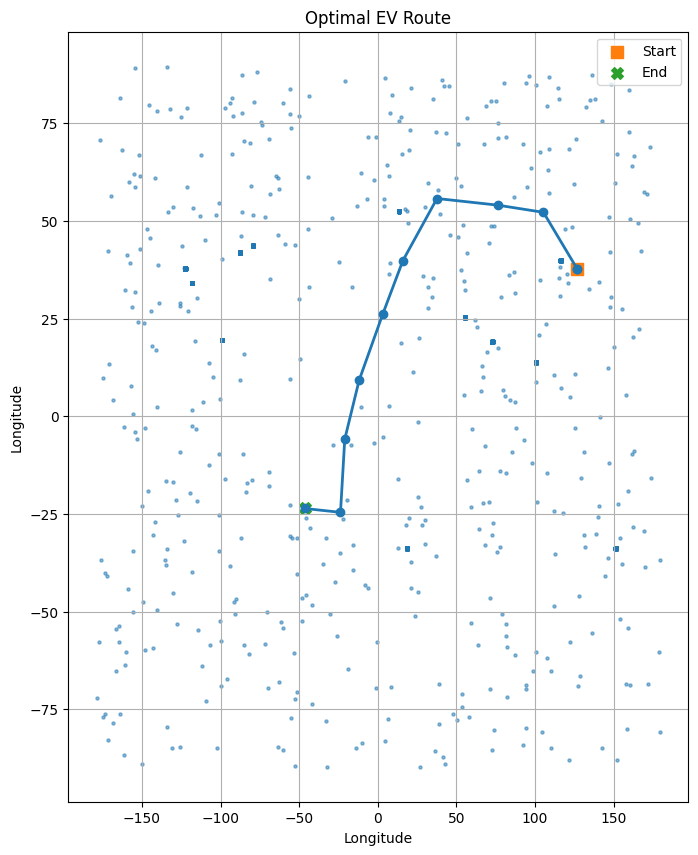

In [148]:
plot_path_on_map(result_ortools['path'], df)

지구본

[2200, 2600]
[{'from': 2200, 'to': 2600, 'drive_time': 3.6175215244293213, 'charge_time': 0.9767308115959168, 'charge_cost': 11.232404333353044, 'energy_used': 48.83654057979584}]


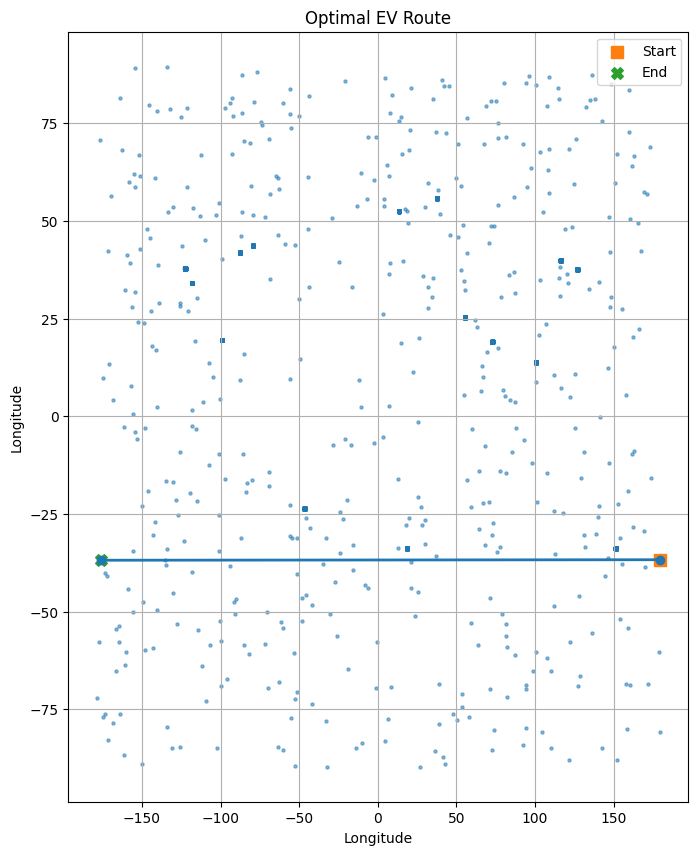

In [149]:
result_ortools_circle = shortest_path_ortools(2200, 2600, cost_matrix)
print(result_ortools_circle['path'])
print(result_ortools_circle['segments'])
plot_path_on_map(result_ortools_circle['path'], df)

##5. 알고리즘과의 비교(Base line)

###1) Greedy Algorithm(재방문 허용)
    - 매 스텝(j)마다 현재 노드(cur)에서 cost_matrix[cur, j]가 가장 작은 j를 선택.
    - 불가능한 간선 (inf / NaN)은 무시.
    - max_steps 이내에 end에 도달하지 못하면 그때까지의 path를 반환.


In [150]:
def shortest_path_greedy(start, end, cost_matrix, max_steps=10000):

    N = cost_matrix.shape[0]

    path = [start]
    cur = start

    for step in range(max_steps):
        if cur == end:
            status = "reached"
            break

        best_j = None
        best_cost = np.inf

        for j in range(N):
            if j == cur:
                continue

            c = cost_matrix[cur, j]
            if not np.isfinite(c):  # 불가능한 간선
                continue

            if c < best_cost:
                best_cost = c
                best_j = j

        if best_j is None:
            # 이 노드에서 나가는 유한 간선이 아예 없는 경우
            status = "incomplete"
            break

        path.append(best_j)
        cur = best_j
    else:
        # for 루프가 max_steps까지 다 돌았는데도 end에 못 감
        status = "incomplete"

    # === 구간별(segment) 세부 비용 생성 ===
    segments = []
    total_cost = 0.0

    for i, j in zip(path[:-1], path[1:]):
        seg_cost = float(cost_matrix[i][j])
        total_cost += seg_cost

        segments.append({
            "from": i,
            "to": j,
            "drive_time":  float(drive_time[i][j]),
            "charge_time": float(charge_time[i][j]),
            "charge_cost": float(charge_cost[i][j]),
            "energy_used": float(energy_needed[i][j]),
        })

    return {
        "path": path,
        "segments": segments,
        "total_cost": total_cost,
        "status": status,
    }


In [151]:
N = cost_matrix.shape[0]
if end_node >= N:
    raise ValueError(f"end_node {end_node} 가 노드 개수 N={N} 보다 큼")

In [152]:
result_greedy = shortest_path_greedy(start_node, end_node, cost_matrix)

print("status:", result_greedy["status"])
print("path length:", len(result_greedy["path"]))
print("total_cost (path 기준):", result_greedy["total_cost"])

status: incomplete
path length: 10001
total_cost (path 기준): 5111.01712249092


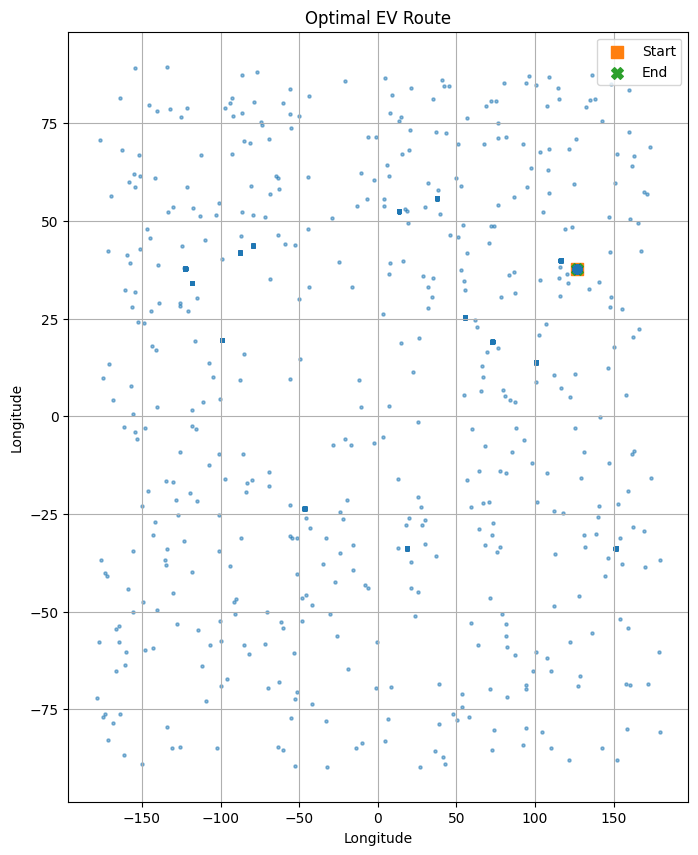

In [153]:
plot_path_on_map(result_greedy["path"], df)

###2) Greedy Algorithm(재방문 금지)
      - 매 스텝마다 현재 노드(cur)에서
        방문 안 한 노드들(j) 중 cost_matrix[cur, j] 최소인 j 선택
      - 이미 방문한 노드는 다시 가지 않음
      - max_steps 이내에 end에 도달 못해도 partial path 반환



In [154]:
def shortest_path_greedy_norevisit(start, end, cost_matrix, max_steps=10000):

    N = cost_matrix.shape[0]
    path = [start]
    visited = set([start])
    cur = start
    status = None

    for step in range(max_steps):
        if cur == end:
            status = "reached"
            break

        best_j = None
        best_cost = np.inf
        for j in range(N):
            if j == cur:
                continue
            if j in visited:
                continue  # 재방문 금지

            c = cost_matrix[cur, j]
            if not np.isfinite(c):
                continue
            if c < best_cost:
                best_cost = c
                best_j = j

        if best_j is None:
            status = "stuck"
            break

        path.append(best_j)
        visited.add(best_j)
        cur = best_j

    if status is None:
        status = "max_steps"

    # 구간별 세부 비용 생성(segment)
    segments = []
    total_cost = 0.0
    for i, j in zip(path[:-1], path[1:]):
        seg_cost = float(cost_matrix[i][j])
        total_cost += seg_cost
        segments.append({
            "from": i,
            "to": j,
            "drive_time":  float(drive_time[i][j]),
            "charge_time": float(charge_time[i][j]),
            "charge_cost": float(charge_cost[i][j]),
            "energy_used": float(energy_needed[i][j]),
        })

    return {
        "path": path,
        "segments": segments,
        "total_cost": total_cost,
        "status": status,
    }


In [155]:
N = cost_matrix.shape[0]
if end_node >= N:
    raise ValueError(f"end_node {end_node} 가 노드 개수 N={N} 보다 큼")

status: reached
path length: 2822
path: [57, 3148, 4843, 4773, 2192, 3166, 3899, 1227, 935, 2635, 1352, 43, 2228, 629, 4214, 812, 3052, 2248, 3466, 821, 2147, 4146, 3984, 125, 1438, 2689, 4053, 451, 1235, 2458, 929, 867, 54, 4834, 1093, 4863, 3043, 933, 289, 543, 3218, 397, 1114, 237, 785, 568, 166, 461, 2825, 1115, 2254, 2993, 2623, 4692, 598, 4354, 528, 2756, 938, 944, 4591, 907, 1238, 2399, 4165, 3385, 1726, 4862, 4841, 3617, 3222, 114, 636, 3713, 1833, 4763, 2123, 3351, 1359, 1236, 4861, 3016, 1424, 2655, 3744, 697, 3667, 171, 4859, 861, 2967, 4058, 428, 4673, 4286, 3379, 4831, 3867, 1802, 4237, 1541, 4271, 3794, 4535, 2965, 3724, 1598, 733, 4743, 175, 339, 1791, 4015, 2771, 3901, 2469, 2226, 993, 4974, 801, 504, 2289, 4079, 251, 1548, 4379, 1042, 4084, 4423, 2334, 1974, 2068, 3753, 531, 1652, 984, 565, 1972, 2657, 437, 4626, 102, 1769, 3866, 4155, 2257, 315, 1729, 1286, 1621, 3082, 2401, 761, 2955, 216, 4684, 4481, 2509, 3441, 1658, 3837, 3261, 1562, 3384, 2053, 842, 4082, 2127, 4

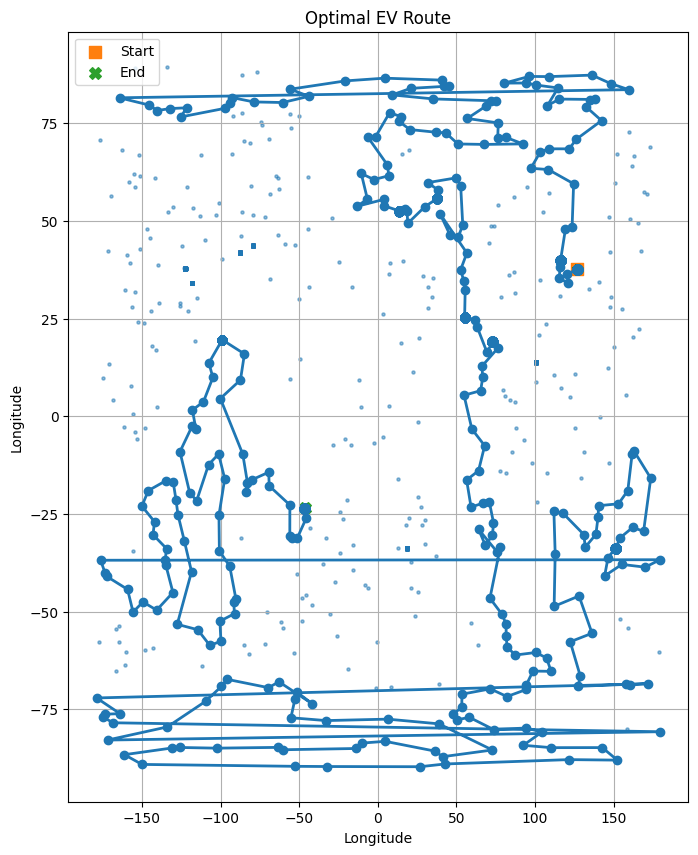

In [156]:
result_greedy_norevisit = shortest_path_greedy_norevisit(start_node, end_node, cost_matrix, max_steps=10000)

print("status:", result_greedy_norevisit["status"])
print("path length:", len(result_greedy_norevisit["path"]))
print("path:", result_greedy_norevisit['path'])

print("total_cost:", result_greedy_norevisit["total_cost"])

baseline_df = pd.DataFrame(result_greedy_norevisit["segments"])
print(baseline_df)

plot_path_on_map(result_greedy_norevisit["path"], df)


##6. 한계점 파악 및 해결

###1) 노드 개수 줄이기

충전량을 연속으로 가져가는 대신, 5000개의 노드 전체를 그대로 사용하면 메모리 및 계산량이 너무 커서 계산 불가.  노드 개수를 15개로 줄이고, 배터리 잔량에 에너지 동역학 제약으로 둠

####(1) 데이터 불러오기 및 전처리

기존 데이터에서 아이디 기준 9~23번 충전소 선택(15개의 노드) → `data/stations_subset_15.xlsx`

In [157]:
df_sub = pd.read_excel(find_data("stations_subset_15.xlsx"))

In [158]:
# 결정 변수(기존과 동일)
battery_capacity_kwh = 70.0 #차량별 베터리 용량
initial_soc_kwh = 1.0 * battery_capacity_kwh #초기 잔량 (kwh)
consumption_per_km = 0.15   #주행 에너지 소모량(kwh/km)
reserve_kwh=5.6             # 최소 잔량 (kwh)
v = 90                      #주행 속력 (km/h)

위도와 경도를 바탕으로 노드 간 거리 계산

In [159]:
coords_sub = list(zip(df_sub["Latitude"], df_sub["Longitude"]))
N = len(coords_sub)
dist_matrix_sub = np.zeros((N, N))
energy_matrix_sub = np.zeros((N, N))  # kWh

for i in range(N):
    for j in range(N):
        if i == j:
            dist = 0.0
        else:
            dist = haversine(coords_sub[i], coords_sub[j])   # km

        dist_matrix_sub[i][j] = dist                                  # km i → j 이동 시 거리 (km)
        energy_matrix_sub[i][j] = dist * consumption_per_km           # i → j 이동에 필요한 배터리 에너지 (kWh) / kWh

그래프가 한 개의 컴포넌트(클러스터)로 구성되게 스케일링

In [160]:
dist_sub = np.array(dist_matrix_sub, dtype=np.float32)

scaled_dist_sub = np.log1p(dist_sub) * 49    # 스케일된 거리
scaled_time_matrix_sub = scaled_dist_sub / v # 스케일된 시간

충전 정보

In [161]:
price_per_kwh_sub = df_sub["Cost (USD/kWh)"].to_numpy(dtype=float)
time_per_kwh_sub = 1.0 / df_sub["Charging Capacity (kW)"].to_numpy(dtype=float)

스케일된 시간을 이용하여 에너지 계산

In [162]:
consumption_per_hour = v * consumption_per_km    # kWh/hour
energy_matrix_sub = scaled_time_matrix_sub * consumption_per_hour  # kWh

####(2) 목적 함수 및 제약 조건 설정

In [163]:
from ortools.linear_solver import pywraplp

In [164]:
def optimize_route_with_charging(
    start_idx,
    end_idx,
    dist_sub,             # (N,N) km
    drive_time_sub,       # (N,N) hour
    energy_needed_sub,    # (N,N) kWh
    time_per_kwh_sub,     # (N,) hour/kWh
    price_per_kwh_sub,    # (N,) cost/kWh
    battery_capacity_kwh,
    reserve_kwh,
    w_drive_time=1.0,
    w_charge_time=1.0,
    w_charge_cost=0.1,
):
    N = dist_sub.shape[0]
    usable_energy = battery_capacity_kwh - reserve_kwh

    solver = pywraplp.Solver.CreateSolver("CBC")
    if solver is None:
        raise RuntimeError("CBC solver 생성 실패")

    # 1x, E, Q 변수
    x = {}
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            x[i, j] = solver.BoolVar(f"x_{i}_{j}")

    E = [solver.NumVar(reserve_kwh, battery_capacity_kwh, f"E_{i}") for i in range(N)]
    Q = [solver.NumVar(0.0, battery_capacity_kwh, f"Q_{i}") for i in range(N)]


    # 제약조건 1. 충전 후 용량 제한
    for i in range(N):
        solver.Add(E[i] + Q[i] <= battery_capacity_kwh)


    # 제약조건 2. 시작 노드는 완충 상태
    solver.Add(E[start_idx] == battery_capacity_kwh)



    # 제약조건 9. path는 출발지->도착지로 한 번만 간다.
    for i in range(N):
        out_flow = []
        in_flow = []
        for j in range(N):
            if i == j:
                continue
            out_flow.append(x[i, j])
            in_flow.append(x[j, i])
        # 출발지: 들어오는 간선 0개, 나가는 간선 1개
        if i == start_idx:
            solver.Add(solver.Sum(out_flow) - solver.Sum(in_flow) == 1)

        # 도착지: 들어오는 간선 1개, 나가는 간선 0개
        elif i == end_idx:
            solver.Add(solver.Sum(out_flow) - solver.Sum(in_flow) == -1)

        # 중간 노드: 들어오는 간선 수 = 나가는 간선 수
        else:
            solver.Add(solver.Sum(out_flow) - solver.Sum(in_flow) == 0)

    # (제약조건 1,3,4,5 결과) 갈 수 없는 간선 막기
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            if dist_sub[i, j] <= 0 or energy_needed_sub[i, j] > usable_energy:
                solver.Add(x[i, j] == 0)

    # 4) 노드 이동 시 에너지 동역학 식 적용 (Big-M)
    M = 2.0 * battery_capacity_kwh

    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            e_need = float(energy_needed_sub[i, j])
            if dist_sub[i, j] <= 0 or e_need > usable_energy:
                continue

            x_ij = x[i, j]

            solver.Add(
                E[j] >= E[i] + Q[i] - e_need - M * (1.0 - x_ij)
            )
            solver.Add(
                E[j] <= E[i] + Q[i] - e_need + M * (1.0 - x_ij)
            )

    # 목적함수
    obj_terms = []

    # (1) 주행 시간
    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            if dist_sub[i, j] <= 0 or energy_needed_sub[i, j] > usable_energy:
                continue
            obj_terms.append(
                x[i, j] * (w_drive_time * float(drive_time_sub[i, j]))
            )

    # (2) 충전 시간 + 충전 비용
    for i in range(N):
        charge_time_coeff = w_charge_time * float(time_per_kwh_sub[i])
        charge_cost_coeff = w_charge_cost * float(price_per_kwh_sub[i])
        obj_terms.append(
            Q[i] * (charge_time_coeff + charge_cost_coeff)
        )

    solver.Minimize(solver.Sum(obj_terms))

    # Solve
    status = solver.Solve()
    if status != pywraplp.Solver.OPTIMAL:
        raise RuntimeError(f"최적해를 찾지 못함 (status: {status})")

    # 경로 재구성
    path = [start_idx]
    cur = start_idx
    while cur != end_idx:
        found = False
        for j in range(N):
            if cur == j:
                continue
            if (cur, j) in x and x[cur, j].solution_value() > 0.5:
                path.append(j)
                cur = j
                found = True
                break
        if not found:
            raise RuntimeError("경로 재구성 실패")

    # 8) 각 부분(세그먼트)별 정보/요약
    segments = []
    total_drive_time = 0.0
    total_charge_time = 0.0
    total_charge_cost = 0.0

    for i, j in zip(path[:-1], path[1:]):
        e_need  = float(energy_needed_sub[i, j])
        drive_t = float(drive_time_sub[i, j])

        E_i_arrive = E[i].solution_value()
        Q_i        = Q[i].solution_value()
        E_i_depart = E_i_arrive + Q_i
        E_j_arrive = E[j].solution_value()

        charge_t = Q_i * float(time_per_kwh_sub[i])
        charge_c = Q_i * float(price_per_kwh_sub[i])

        segments.append({
            "from": int(i),
            "to": int(j),
            "drive_time":      drive_t,
            "energy_needed":   e_need,
            "energy_arrive_i": E_i_arrive,
            "energy_depart_i": E_i_depart,
            "charge_energy":   Q_i,
            "charge_time":     charge_t,
            "charge_cost":     charge_c,
            "energy_arrive_j": E_j_arrive,
        })

        total_drive_time  += drive_t
        total_charge_time += charge_t
        total_charge_cost += charge_c

    result = {
        "path": path,
        "segments": segments,
        "total_drive_time":  total_drive_time,
        "total_charge_time": total_charge_time,
        "total_charge_cost": total_charge_cost,
        "total_objective":   solver.Objective().Value(),
    }
    return result


####(3) 실행

In [165]:
# 15개 노드(df_sub) 기준 행렬/벡터 사용
drive_time_sub = scaled_time_matrix_sub.astype(float)   # (N,N) 스케일된 주행시간
# time_per_kwh_sub, price_per_kwh_sub 는 위 '충전 정보' 셀에서 df_sub 기준으로 계산됨

N = len(df_sub)
print("노드 개수 N =", N)

start_idx = 0      # 출발 노드 인덱스
end_idx   = 10     # 도착 노드 인덱스 (원하는 대로 바꿔)

# 인덱스 체크
if not (0 <= start_idx < N and 0 <= end_idx < N):
    raise ValueError("start_idx / end_idx 가 df 인덱스 범위 밖임")

result_charging = optimize_route_with_charging(
    start_idx=start_idx,
    end_idx=end_idx,
    dist_sub=dist_sub,
    drive_time_sub=drive_time_sub,
    energy_needed_sub=energy_matrix_sub,
    time_per_kwh_sub=time_per_kwh_sub,
    price_per_kwh_sub=price_per_kwh_sub,
    battery_capacity_kwh=battery_capacity_kwh,
    reserve_kwh=reserve_kwh,
    w_drive_time=1.0,
    w_charge_time=1.0,
    w_charge_cost=0.1,
)

print("최적 경로 (노드 인덱스):", result_charging["path"])
print("총 주행시간:", result_charging["total_drive_time"])
print("총 충전시간:", result_charging["total_charge_time"])
print("총 충전비용:", result_charging["total_charge_cost"])
print("목적함수값:", result_charging["total_objective"])

for k, seg in enumerate(result_charging["segments"], 1):
    print(f"\nSegment {k}: {seg['from']} -> {seg['to']}")
    print(f"  drive_time       = {seg['drive_time']:.3f} h")
    print(f"  energy_needed    = {seg['energy_needed']:.3f} kWh")
    print(f"  E_arrive(i)      = {seg['energy_arrive_i']:.3f} kWh")
    print(f"  charge_energy    = {seg['charge_energy']:.3f} kWh")
    print(f"  E_depart(i)      = {seg['energy_depart_i']:.3f} kWh")
    print(f"  charge_time      = {seg['charge_time']:.3f} h")
    print(f"  charge_cost      = {seg['charge_cost']:.3f}")
    print(f"  E_arrive(j)      = {seg['energy_arrive_j']:.3f} kWh")

노드 개수 N = 15
최적 경로 (노드 인덱스): [0, 12, 13, 1, 10]
총 주행시간: 17.598961114883423
총 충전시간: 0.9092398122151693
총 충전비용: 42.555036308288564
목적함수값: 22.763704557927447

Segment 1: 0 -> 12
  drive_time       = 4.571 h
  energy_needed    = 61.706 kWh
  E_arrive(i)      = 70.000 kWh
  charge_energy    = 0.000 kWh
  E_depart(i)      = 70.000 kWh
  charge_time      = 0.000 h
  charge_cost      = 0.000
  E_arrive(j)      = 8.294 kWh

Segment 2: 12 -> 13
  drive_time       = 4.576 h
  energy_needed    = 61.777 kWh
  E_arrive(i)      = 8.294 kWh
  charge_energy    = 59.082 kWh
  E_depart(i)      = 67.377 kWh
  charge_time      = 0.394 h
  charge_cost      = 17.725
  E_arrive(j)      = 5.600 kWh

Segment 3: 13 -> 1
  drive_time       = 4.717 h
  energy_needed    = 63.677 kWh
  E_arrive(i)      = 5.600 kWh
  charge_energy    = 64.400 kWh
  E_depart(i)      = 70.000 kWh
  charge_time      = 0.184 h
  charge_cost      = 6.440
  E_arrive(j)      = 6.323 kWh

Segment 4: 1 -> 10
  drive_time       = 3.735 h
  ene

####(4) 시각화

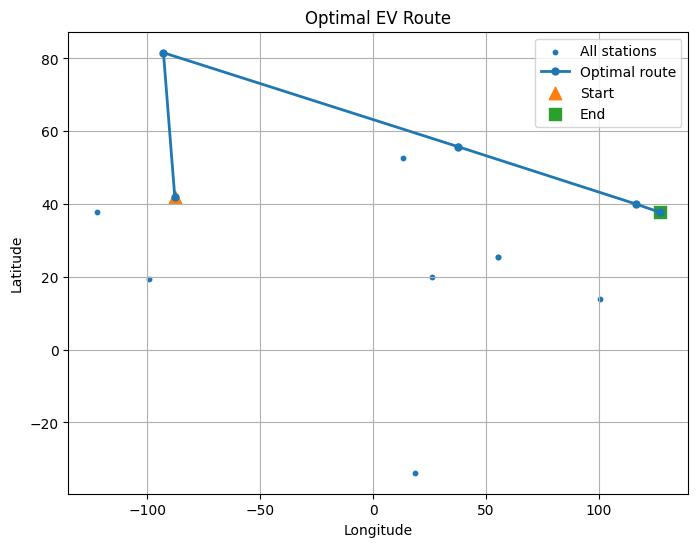

In [166]:
path_sub = result_charging["path"]

# 경로에 포함된 위도/경도
path_lats = df_sub.loc[path_sub, "Latitude"].to_numpy()
path_lons = df_sub.loc[path_sub, "Longitude"].to_numpy()

plt.figure(figsize=(8, 6))

# 전체 충전소 (배경)
plt.scatter(df_sub["Longitude"], df_sub["Latitude"], s=10, alpha=1, label="All stations")

# 최적 경로 (선 + 점)
plt.plot(path_lons, path_lats, marker="o", linewidth=2, markersize=5, label="Optimal route")

# 출발/도착 강조
plt.scatter(path_lons[0], path_lats[0], s=80, marker="^", label="Start")
plt.scatter(path_lons[-1], path_lats[-1], s=80, marker="s", label="End")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Optimal EV Route")
plt.legend()
plt.grid(True)
plt.show()

###2) 충전량 선택

In [167]:
# 이산 배터리 충전량 단계(0%, 30%, 50%, 70%, 100%) 설정 (kWh 기준)
soc_levels_frac = np.array([0.0, 0.3, 0.5, 0.7, 1.0])
soc_levels_kwh  = soc_levels_frac * battery_capacity_kwh  # [0, 21, 35, 49, 70]
num_soc_levels  = len(soc_levels_kwh)

def state_id(i, s_idx):
    """충전소 i, SOC 단계 index s_idx -> 상태노드 id"""
    return i * num_soc_levels + s_idx

N = scaled_time_matrix.shape[0]
energy_scaled = scaled_time_matrix * consumption_per_hour  # (N,N)
can_travel = (scaled_time_matrix < 4.77)
total_states = N * num_soc_levels
SUPER_SINK   = total_states   # 마지막에 sink 하나 추가


In [168]:
# 가중치 (원하면 바꿔가면서 튜닝)
w_drive_time  = 1.0   # 주행 시간 비중
w_charge_time = 1.0   # 충전 시간 비중
w_charge_cost = 0.1   # 충전 금액 비중

def shortest_path_discrete_soc_with_charging(start_node, end_node):
    smcf = min_cost_flow.SimpleMinCostFlow()

    # ---------- 1) 이동(주행) 간선 ----------
    for i in range(N):
        for s_idx in range(num_soc_levels):
            soc_i = soc_levels_kwh[s_idx]   # 현재 SOC (kWh, 가상세계에서도 에너지 단위는 그대로 사용)
            if soc_i < reserve_kwh:
                continue  # 최소 잔량보다 낮으면 출발 불가

            for j in range(N):
                if i == j:
                    continue
                if not can_travel[i, j]:
                    continue  # scaled_time >= 4.77인 간선은 연결 안 함

                e_ij = energy_scaled[i, j]   # 이 leg에서 소모되는 에너지 (kWh)
                if e_ij <= 0:
                    continue

                new_soc = soc_i - e_ij
                if new_soc < reserve_kwh:
                    continue  # 최소 잔량 못 지키면 이 SOC 상태에서는 이 간선 사용 불가

                # new_soc 이하에서 가능한 SOC 단계 중 가장 높은 것 (아래로 스냅)
                possible = np.where(soc_levels_kwh <= new_soc)[0]
                if len(possible) == 0:
                    continue
                s2_idx = possible.max()

                u = state_id(i, s_idx)
                v = state_id(j, s2_idx)

                # 이동 비용 = 스케일링된 시간만 사용
                drive_cost = w_drive_time * scaled_time_matrix[i, j]
                unit_cost  = int(drive_cost * 1000)

                smcf.add_arc_with_capacity_and_unit_cost(
                    u, v,
                    1,
                    unit_cost
                )

    # ---------- 2) 충전 간선 (0→30→70→100 순차 충전 + 비용 반영) ----------
    for i in range(N):
        for s_idx in range(num_soc_levels - 1):
            soc_from = soc_levels_kwh[s_idx]
            soc_to   = soc_levels_kwh[s_idx + 1]
            delta_e  = soc_to - soc_from   # 이 단계에서 추가로 채우는 에너지 (kWh)

            if delta_e <= 0:
                continue

            # 이 delta_e를 충전소 i에서 채우는 데 걸리는 "물리적 시간/비용"
            t_charge_phys = delta_e * time_per_kwh[i]      # 시간 (hours)
            c_charge_phys = delta_e * price_per_kwh[i]     # 비용 (USD)

            # (3) 충전 시간도 스케일링: log(1 + t)
            #     크기 맞추고 싶으면 *alpha 같은 상수 더 곱해도 됨.
            t_charge_scaled = np.log1p(t_charge_phys)

            charge_cost = (
                w_charge_time * t_charge_scaled +
                w_charge_cost * c_charge_phys
            )

            u = state_id(i, s_idx)
            v = state_id(i, s_idx + 1)

            unit_cost = int(charge_cost * 1000)

            smcf.add_arc_with_capacity_and_unit_cost(
                u, v,
                1,
                unit_cost
            )

    # ---------- 3) SUPER_SINK로 가는 간선 (end_node의 모든 SOC 상태) ----------
    for s_idx in range(num_soc_levels):
        soc_val = soc_levels_kwh[s_idx]
        if soc_val < reserve_kwh:
            continue
        u = state_id(end_node, s_idx)
        v = SUPER_SINK
        smcf.add_arc_with_capacity_and_unit_cost(
            u, v,
            1,
            0  # 도착 자체에는 추가 비용 없음
        )

    # ---------- 4) 공급/수요 설정 ----------
    total_nodes = total_states + 1  # SUPER_SINK 포함
    start_state = state_id(start_node, num_soc_levels - 1)  # start에서 SOC=100%
    sink_state  = SUPER_SINK

    supplies = [0] * total_nodes
    supplies[start_state] = 1
    supplies[sink_state]  = -1

    for node in range(total_nodes):
        smcf.set_node_supply(node, supplies[node])

    # ---------- 5) 최적화 ----------
    status = smcf.solve()
    if status != smcf.OPTIMAL:
        raise RuntimeError(f"Min cost flow did not find optimal solution. Status: {status}")

    # ---------- 6) 경로 복원 ----------
    path_states = [start_state]
    current = start_state
    total_cost_int = 0

    while current != sink_state:
        found_next = False
        for arc_id in range(smcf.num_arcs()):
            if smcf.tail(arc_id) == current and smcf.flow(arc_id) > 0:
                nxt = smcf.head(arc_id)
                path_states.append(nxt)
                total_cost_int += smcf.unit_cost(arc_id)
                current = nxt
                found_next = True
                break
        if not found_next:
            raise RuntimeError("Path reconstruction failed.")

    total_cost = total_cost_int / 1000.0

    # 상태 id → (노드 index, SOC 단계 index)로 변환
    path_node_soc = []
    for st in path_states:
        if st == SUPER_SINK:
            path_node_soc.append(("SINK", None))
        else:
            node_idx = st // num_soc_levels
            soc_idx  = st % num_soc_levels
            path_node_soc.append((node_idx, soc_idx))

    return path_node_soc, total_cost



    shortest_path_discrete_soc_with_charging() 이 반환한 path_node_soc를 받아서
    각 스텝마다
      - 이동인지(주행) / 충전인지
      - 이동 시간(물리 시간, 스케일 시간)
      - 충전 시간
      - 충전 비용
    등을 표로 정리해서 DataFrame으로 돌려준다.


In [169]:
def analyze_path_steps(path_node_soc):

    records = []

    total_drive_time_h = 0.0
    total_charge_time_h = 0.0
    total_charge_cost  = 0.0

    for step in range(len(path_node_soc) - 1):
        from_state = path_node_soc[step]
        to_state   = path_node_soc[step + 1]

        # 마지막은 ("SINK", None) 로 끝나므로 거기서 멈춘다
        if from_state[0] == "SINK" or to_state[0] == "SINK":
            break

        from_node, from_soc_idx = from_state
        to_node,   to_soc_idx   = to_state

        from_soc_kwh = soc_levels_kwh[from_soc_idx]
        to_soc_kwh   = soc_levels_kwh[to_soc_idx]

        rec = {
            "step": step,
            "from_node": int(from_node),
            "to_node": int(to_node),
            "from_soc_idx": int(from_soc_idx),
            "to_soc_idx": int(to_soc_idx),
            "from_soc_kwh": float(from_soc_kwh),
            "to_soc_kwh": float(to_soc_kwh),
        }

        if from_node != to_node:
            # ===== 주행 스텝 =====
            rec["type"] = "drive"

            # 스케일된 시간
            drive_time_scaled = float(scaled_time_matrix[from_node, to_node])

            # 사용한 에너지 (이산 SOC 기준)
            energy_used_kwh = float(from_soc_kwh - to_soc_kwh)

            rec["drive_time_scaled"] = drive_time_scaled
            rec["energy_used_kwh"]   = energy_used_kwh
            total_drive_time_h += drive_time_scaled

            # 충전 관련은 없음
            rec["charge_time_h"] = 0.0
            rec["charge_cost"]   = 0.0


        else:
            # ===== 충전 스텝 =====
            rec["type"] = "charge"

            delta_e_kwh = float(to_soc_kwh - from_soc_kwh)  # 충전량 (kWh)

            # 물리적 충전 시간/비용 (우리가 간선 만들 때 썼던 그대로)
            t_charge_h = float(delta_e_kwh * time_per_kwh[from_node])
            c_charge   = float(delta_e_kwh * price_per_kwh[from_node])

            rec["drive_time_scaled"] = 0.0
            rec["energy_used_kwh"]   = -delta_e_kwh  # 충전이라 음수로 표기해둠 (원하면 바꿔도 됨)

            rec["charge_time_h"] = t_charge_h
            rec["charge_cost"]   = c_charge

            total_charge_time_h += t_charge_h
            total_charge_cost   += c_charge

        # 누적 값들
        rec["cum_drive_time_h"]  = total_drive_time_h
        rec["cum_charge_time_h"] = total_charge_time_h
        rec["cum_charge_cost"]   = total_charge_cost

        records.append(rec)

    df = pd.DataFrame(records)
    return df


path_discrete: shortest_path_discrete_soc_with_charging()의 결과라고 가정

    (node_idx, soc_idx) 경로에서,
    실제로 from_node != to_node 인 스텝들만 모아서
    순수 '노드 방문 순서'를 반환.
    예: [(0,3), (3300,0), (3300,1), ..., (10,1), ('SINK', None)]
    예: [0, 3300, 2880, ..., 10]


In [170]:
def extract_travel_nodes(path_discrete):

    travel_nodes = []

    for k in range(len(path_discrete) - 1):
        cur = path_discrete[k]
        nxt = path_discrete[k + 1]

        if cur[0] == "SINK" or nxt[0] == "SINK":
            break

        from_node, _ = cur
        to_node,   _ = nxt

        if from_node != to_node:
            # 이동하는 스텝
            if not travel_nodes:
                travel_nodes.append(from_node)
            travel_nodes.append(to_node)

    # 중복 제거(혹시라도) + 순서 유지
    # (여기서는 필요 없을 가능성이 크지만, 안전하게)
    cleaned = []
    for node in travel_nodes:
        if not cleaned or cleaned[-1] != node:
            cleaned.append(node)

    return cleaned

In [172]:
start_node = 57
end_node   = 3482

path_discrete, cost_discrete = shortest_path_discrete_soc_with_charging(start_node, end_node)

print("총 비용:", cost_discrete)
print("경로 (node_idx, soc_idx):", path_discrete)

총 비용: 63.576
경로 (node_idx, soc_idx): [(57, 4), (2970, 0), (2970, 1), (2970, 2), (2970, 3), (2970, 4), (1000, 0), (1000, 1), (1000, 2), (1000, 3), (1000, 4), (21, 0), (21, 1), (21, 2), (21, 3), (21, 4), (4050, 0), (4050, 1), (4050, 2), (4050, 3), (4050, 4), (2860, 0), (2860, 1), (2860, 2), (2860, 3), (2860, 4), (3230, 0), (3230, 1), (3230, 2), (3230, 3), (3230, 4), (3410, 0), (3410, 1), (3410, 2), (3410, 3), (3410, 4), (1960, 0), (1960, 1), (1960, 2), (1960, 3), (1960, 4), (3482, 0), (3482, 1), ('SINK', None)]


In [173]:
# 스텝별 상세 분석
df_steps = analyze_path_steps(path_discrete)
print(df_steps)

print("\n요약:")
print("총 충전 시간(h):", df_steps["charge_time_h"].sum())
print("총 충전 비용(USD):", df_steps["charge_cost"].sum())

    step  from_node  to_node  from_soc_idx  to_soc_idx  from_soc_kwh  \
0      0         57     2970             4           0          70.0   
1      1       2970     2970             0           1           0.0   
2      2       2970     2970             1           2          21.0   
3      3       2970     2970             2           3          35.0   
4      4       2970     2970             3           4          49.0   
5      5       2970     1000             4           0          70.0   
6      6       1000     1000             0           1           0.0   
7      7       1000     1000             1           2          21.0   
8      8       1000     1000             2           3          35.0   
9      9       1000     1000             3           4          49.0   
10    10       1000       21             4           0          70.0   
11    11         21       21             0           1           0.0   
12    12         21       21             1           2          

In [174]:
route_nodes = extract_travel_nodes(path_discrete)
print("방문 노드 순서:", route_nodes)

방문 노드 순서: [57, 2970, 1000, 21, 4050, 2860, 3230, 3410, 1960, 3482]


시각화

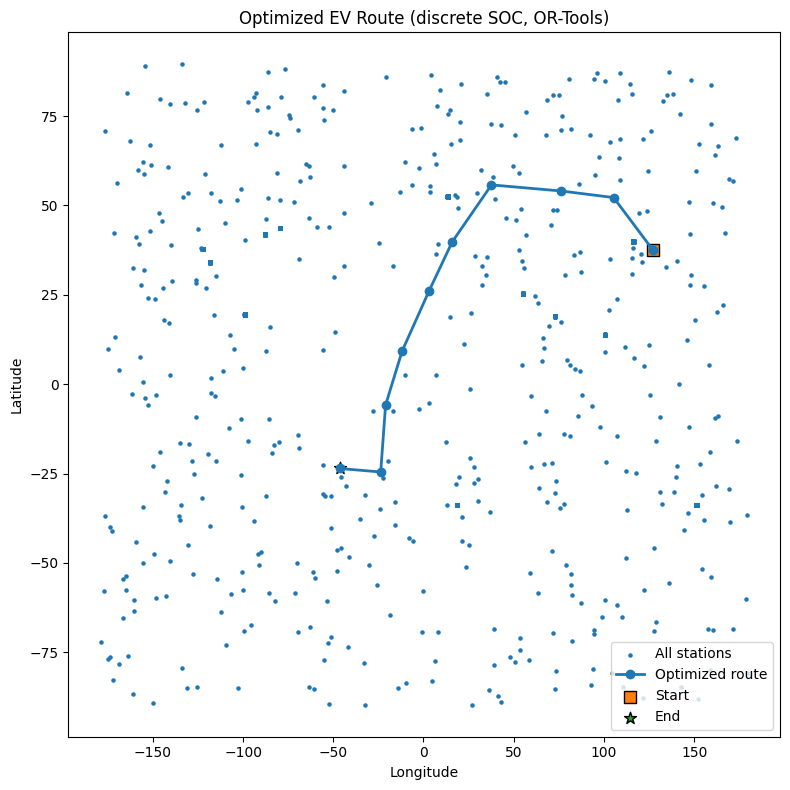

In [175]:
# 전체 충전소 좌표
all_lats = df["Latitude"].to_numpy()
all_lons = df["Longitude"].to_numpy()

# 경로에 해당하는 노드들의 좌표
route_lats = [all_lats[i] for i in route_nodes]
route_lons = [all_lons[i] for i in route_nodes]

plt.figure(figsize=(8, 8))

# 1) 전체 충전소 (연한 회색 점)
plt.scatter(all_lons, all_lats, s=5, alpha=1, label="All stations")

# 2) 경로 위의 노드들 (굵은 선 + 점)
plt.plot(route_lons, route_lats, linewidth=2, marker="o", markersize=6, label="Optimized route")

# 3) 시작/도착 노드 강조
start_idx = route_nodes[0]
end_idx   = route_nodes[-1]

plt.scatter(all_lons[start_idx], all_lats[start_idx],
            s=80, marker="s", label="Start", edgecolors="black")
plt.scatter(all_lons[end_idx], all_lats[end_idx],
            s=80, marker="*", label="End", edgecolors="black")

# 4) 보기 좋게 라벨/제목/범례
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Optimized EV Route (discrete SOC, OR-Tools)")
plt.legend()
plt.tight_layout()
plt.show()
